# Анализ оттока клиентов (Telco Churn)

In [2]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Предобработка. Колонка TotalCharges содержала неявные пробелы у новых клиентов. Заполняем пустоты нулями и приводим к типу float64.

In [3]:
print("Типы данных ДО:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)
print("-" * 30)

# 2. Конвертация строк в числа
# Параметр errors='coerce' заставит pandas заменить все нечитаемые символы (включая пробелы) на NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Посмотрим, сколько пропусков у нас образовалось
missing_values = df['TotalCharges'].isna().sum()
print(f"Найдено пропусков (NaN) после конвертации: {missing_values}")

# 3. Исследование природы пропусков
# Посмотрим на строки, где TotalCharges равно NaN
new_clients = df[df['TotalCharges'].isna()]
print("\nКлиенты с пропусками в TotalCharges:")
print(new_clients[['tenure', 'MonthlyCharges', 'TotalCharges']])

# 4. Заполнение пропусков
# Как видно из вывода выше, tenure (срок обслуживания) у этих клиентов равен 0. 
# Это новые клиенты, они еще не успели ничего заплатить. Логично заменить их TotalCharges на 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Проверяем результат
print("-" * 30)
print("Типы данных ПОСЛЕ:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)
print(f"Осталось пропусков: {df['TotalCharges'].isna().sum()}")

Типы данных ДО:
tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object
------------------------------
Найдено пропусков (NaN) после конвертации: 11

Клиенты с пропусками в TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN
------------------------------
Типы данных ПОСЛЕ:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
Осталось пропусков: 0


In [4]:
summary = df.groupby('Churn').agg({
    'customerID' : 'count',       # Считаем количество клиентов (аналог COUNT)
    'tenure': 'mean',            # Средний срок обслуживания
    'MonthlyCharges': 'mean',    # Средний чек
    'TotalCharges': 'mean'       # Средняя сумма за всё время
})
summary = summary.rename(columns={'customerID': 'Users_Count'})

# Выводим результат
display(summary)

,Users_Count,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,5174,37.569965,61.265124,2549.911442
Yes,1869,17.979133,74.441332,1531.796094


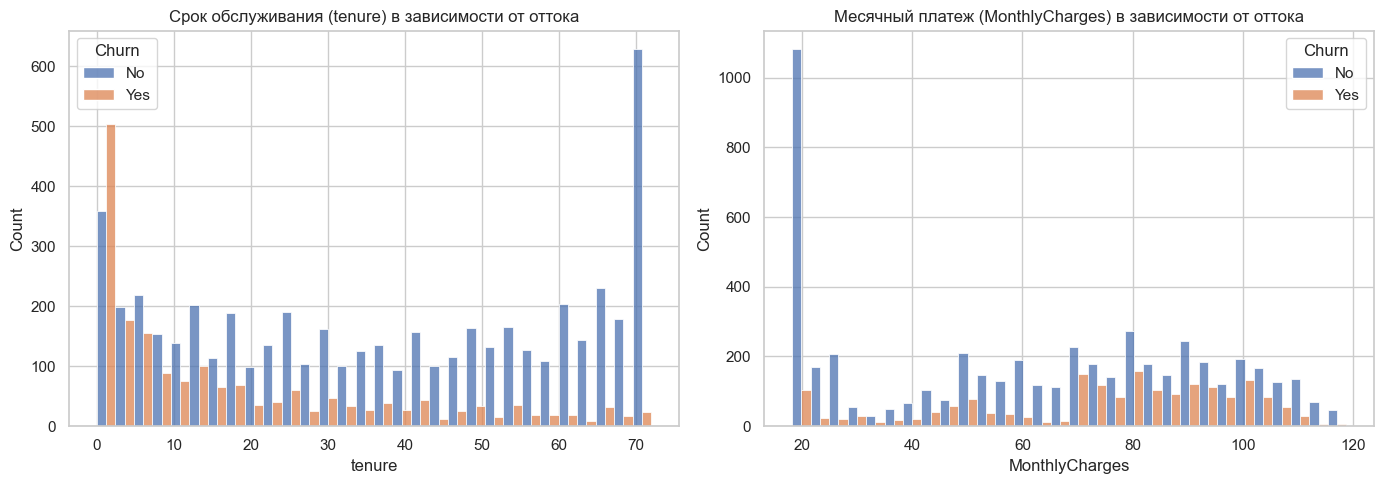

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")

# Создаем "холст" для двух графиков (1 строка, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Гистограмма для tenure (срок жизни)
sns.histplot(data=df, x='tenure', hue='Churn', multiple="dodge", bins=30, ax=axes[0])
axes[0].set_title('Срок обслуживания (tenure) в зависимости от оттока')

# График 2: Гистограмма для MonthlyCharges (ежемесячный платеж)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple="dodge", bins=30, ax=axes[1])
axes[1].set_title('Месячный платеж (MonthlyCharges) в зависимости от оттока')

plt.tight_layout()
plt.show()

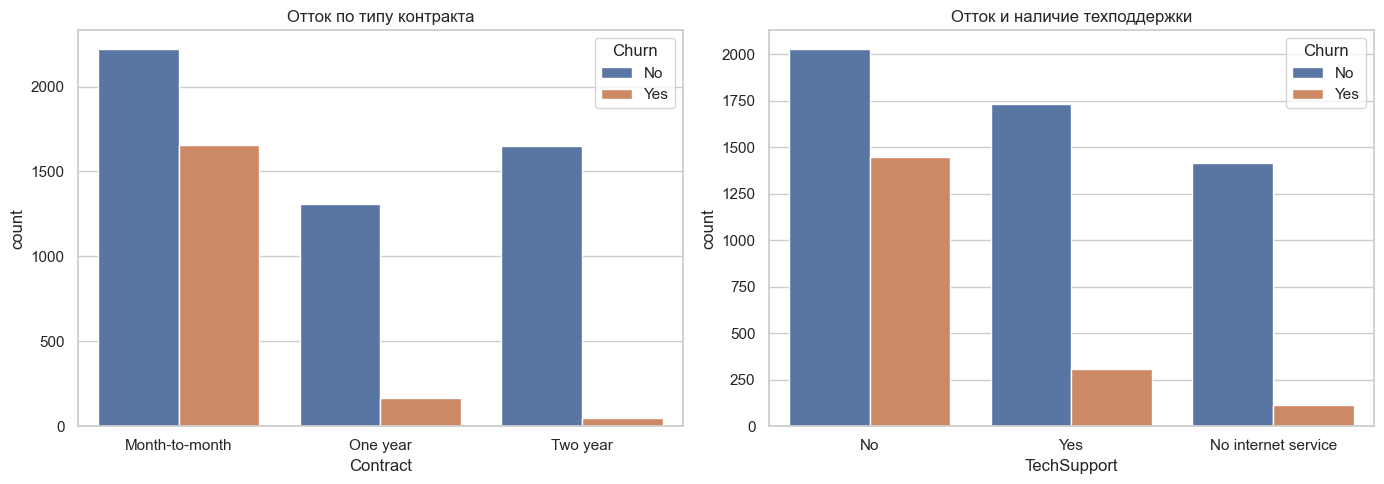

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Влияние типа контракта на отток
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Отток по типу контракта')

# Влияние наличия технической поддержки
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1])
axes[1].set_title('Отток и наличие техподдержки')

plt.tight_layout()
plt.show()

In [7]:
# Смотрим на текстовые колонки до трансформации
print("До кодирования (пример столбца Contract):")
print(df['Contract'].head(3))
print("-" * 30)

# pd.get_dummies автоматически находит текстовые колонки (object) 
# и превращает их в бинарные признаки (0 и 1)
# drop_first=True удаляет один лишний столбец во избежание мультиколлинеарности
df_encoded = pd.get_dummies(df, drop_first=True)

# Чтобы столбцы были красиво представлены числами 0 и 1, а не True/False:
df_encoded = df_encoded.astype(int)

# Смотрим результат
print("После кодирования:")
print(df_encoded[['Contract_One year', 'Contract_Two year']].head(3))
print("-" * 30)
print(f"Количество признаков выросло с {df.shape[1]} до {df_encoded.shape[1]}")

До кодирования (пример столбца Contract):
0    Month-to-month
1          One year
2    Month-to-month
Name: Contract, dtype: str
------------------------------
После кодирования:
   Contract_One year  Contract_Two year
0                  0                  0
1                  1                  0
2                  0                  0
------------------------------
Количество признаков выросло с 21 до 7073


In [9]:
# 1. Удаляем customerID (он уникален для каждого и не несет смысла для модели)
df_clean = df.drop('customerID', axis=1)

# 2. Теперь кодируем категории — получится всего около 30 столбцов вместо 7000!
df_encoded = pd.get_dummies(df_clean, drop_first=True).astype(int)

print(f"Итоговый размер таблицы: {df_encoded.shape}") 
# Должно получиться: (7043, 31)

Итоговый размер таблицы: (7043, 31)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Отделяем матрицу признаков (X) от вектора ответов (y)
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# 2. Делим выборку на обучающую (80%) и тестовую (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Масштабируем данные (стандартизация)
scaler = StandardScaler()
# Обучаем скейлер только на тренировочной выборке!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Создаем и обучаем алгоритм логистической регрессии
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 5. Делаем предсказания на тестовых данных и выводим отчет
predictions = model.predict(X_test_scaled)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [11]:
# 1. Создаем новую модель, но добавляем аргумент class_weight='balanced'
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)

# 2. Обучаем на тех же отмасштабированных данных
model_balanced.fit(X_train_scaled, y_train)

# 3. Делаем новые предсказания
predictions_balanced = model_balanced.predict(X_test_scaled)

# 4. Выводим отчет
print("--- Модель с балансировкой весов ---")
print(classification_report(y_test, predictions_balanced))

--- Модель с балансировкой весов ---
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



### Бизнес-вывод

На первый взгляд вторая модель может показаться менее эффективной из-за снижения общей точности (Accuracy). Однако благодаря балансировке классов алгоритм с гораздо меньшей вероятностью упускает клиентов, действительно склонных к оттоку (рост метрики Recall). 

С точки зрения юнит-экономики это намного важнее: предотвращение реальной потери клиента сохраняет компании больше денег, чем она теряет на ошибочно предложенных бонусах лояльным пользователям.